In [1]:
from tempfile import TemporaryDirectory

import pandas as pd

import scarf
from scarf.tools.repack_zarr import repack_store

scarf.configure_output(level='WARNING', progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name='bastidas-ponce_4K_pancreas-d15_rnaseq',
    destination='scarf_datasets',
    zarr=True,
)

analysis_directory = TemporaryDirectory()
repacked_counts = f'{analysis_directory.name}/counts.zarr'
repack_store(
    f'{dataset}/data.zarr',
    repacked_counts,
    nthreads=2,
)
ds = scarf.mount_datastore(
    repacked_counts,
    at=f'{analysis_directory.name}/analysis.zarr',
    nthreads=4,
    default_assay='RNA',
)
hvg_ref = ds.mark_hvgs(
    top_n=2000,
    show_plot=False,
    label='expression_hvgs',
)
normalized = ds.run_normalization(features=hvg_ref)
reduction = ds.run_pca(normalized, dims=15)
ann_index = ds.build_ann_index(reduction)
neighbors = ds.query_neighbors(ann_index, k=11)
graph = ds.build_connectivity_map(neighbors)
all_features = ds.resolve_features('RNA', 'all_features')

pseudotime = ds.run_pseudotime_scoring(
    graph,
    source_sink_key='clusters',
    sources=['Ductal'],
    sinks=['Alpha', 'Beta', 'Delta'],
)
pseudotime_key = pseudotime.pseudotime_key
validity_key = pseudotime.validity_key

Downloading bucket files: 43423201 / 43423201 complete

Downloading bytes: 43423201 / 43423201 complete

Repacking RNA/artifacts/reduction//data: 1 / 1 complete

Repacking RNA/artifacts/reduction//loadings: 1 / 1 complete

Repacking RNA/artifacts/connectivity_map//edges: 1 / 1 complete

...

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

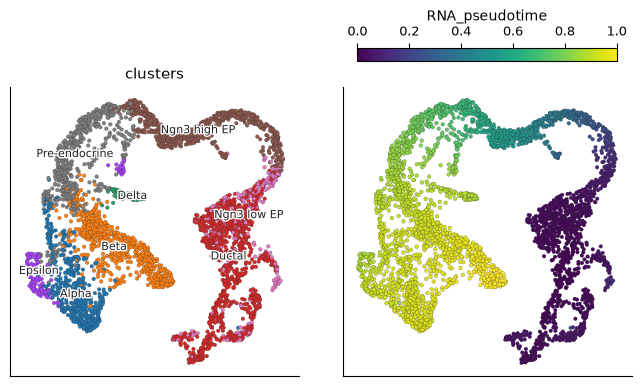

In [2]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=['clusters', pseudotime_key],
    n_columns=2,
    legend_loc='on_data',
)

In [3]:
modules = ds.run_pseudotime_aggregation(
    features=all_features,
    cell_key=validity_key,
    pseudotime_key=pseudotime_key,
    cluster_label='pseudotime_clusters',
    n_clusters=15,
    window_size=200,
    chunk_size=100,
)

Binning over cell-ordering: 2 / 2 complete

Fitting feature KNN: 1 / 1 complete

Identifying feature neighbors: 1 / 1 complete

Sorting clusters: 1 / 1 complete

In [4]:
ptime_feat = ds.RNA.feats.to_pandas_dataframe(
    columns=['names', modules.cluster_key]
)
ptime_feat[modules.cluster_key].value_counts().sort_index()

pseudotime_clusters
-1     15543
 1       783
 2       963
 3       718
 4       849
 5       407
 6       953
 7      1385
 8      1177
 9       724
 10      757
 11       59
 12     1113
 13     1123
 14      634
 15      810
Name: count, dtype: int64

In [5]:
assigned = ptime_feat[ptime_feat[modules.cluster_key] != -1]
representatives = (
    assigned.groupby(modules.cluster_key, sort=True)['names']
    .first()
    .rename('representative gene')
)
representatives

pseudotime_clusters
1      Sbspon
2       Pkhd1
3        Rpl7
4      Lactb2
5       Prim2
6      Mrpl15
7       Smap1
8       Cops5
9     Ppp1r42
10     Vcpip1
11      Lace1
12      Tcf24
13      Ncoa2
14    Arfgef1
15      Tram1
Name: representative gene, dtype: str

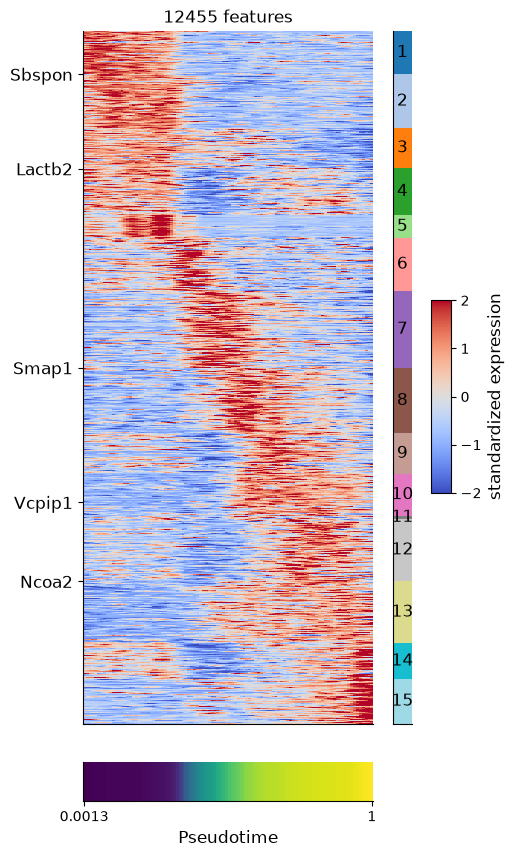

In [6]:
genes_to_label = representatives.iloc[::3].tolist()

ds.plots.pseudotime_heatmap(
    cell_key=modules.cell_key,
    features=modules.feature_selection,
    feature_cluster_key=modules.cluster_key,
    pseudotime_key=modules.pseudotime_key,
    show_features=genes_to_label,
)

In [7]:
ds.add_grouped_assay(
    group_key=modules.cluster_key,
    assay_label='PTIME_MODULES'
)

Computing grouped means: 15 / 15 complete

Writing grouped assay: 1 / 1 complete

Computing PTIME_MODULES initialization statistics: 1 / 1 complete

In [8]:
module_features = ds.PTIME_MODULES.feats.fetch_all('names').tolist()
{
    "module count": len(module_features),
    "cells": int(ds.PTIME_MODULES.rawData.shape[0]),
    "first modules": module_features[:5],
}

{'module count': 15,
 'cells': 3696,
 'first modules': ['group_1', 'group_2', 'group_3', 'group_4', 'group_5']}

In [9]:
pd.DataFrame(
    ds.PTIME_MODULES.rawData[:5, :5].compute(),
    columns=module_features[:5],
)

,group_1,group_2,group_3,group_4,group_5
0,0.034030,0.039826,0.232782,0.061342,0.011903
1,0.077665,0.092666,0.415482,0.060467,0.026756
2,0.031379,0.046946,0.267259,0.051224,0.019318
3,0.084002,0.088915,0.424467,0.067049,0.070225
4,0.025665,0.038016,0.305930,0.033981,0.017599


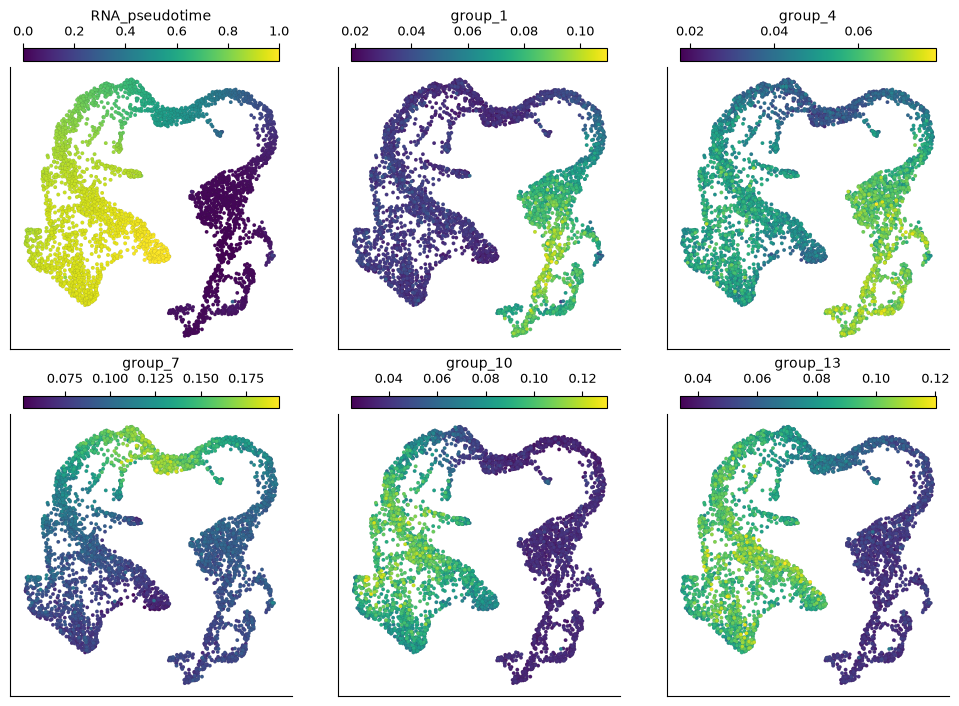

In [10]:
selected_modules = [
    f"group_{module_id}" for module_id in representatives.iloc[::3].index
]
ds.plots.embedding(
    from_assay='PTIME_MODULES',
    layout_key='RNA_UMAP',
    color_by=[pseudotime_key, *selected_modules],
    n_columns=3,
    sort_values=True,
)